In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os
import json
import k3d
import time
import lc_reconstruction_analysis.utils as utils
import lc_reconstruction_analysis.dendritic as dendritic
import lc_reconstruction_analysis.clustering as clustering
import lc_reconstruction_analysis.axon as axon
import lc_reconstruction_analysis.correlation as correlation
%matplotlib inline

## Assemble data

In [2]:
DATA_DIR = Path("../data/LC_Snapshots")
BASE_DIR = Path("../data/")
SAVE_DIR = Path("../results/")

In [3]:
dataDF, graphs = utils.load_cells(DATA_DIR)

### Plotting example reconstructions

In [4]:
# Establish camera views
topdownVertical = [12000, -10000, 5700, 9000, 0, 5700, -1, 0, 0]
topdownHorizontal = [9000, -9000, 5700, 9000, 0, 5700, 0, 0, 1]
topdownAngled = [7000, -12000, 0, 7000, 0, 5700, -.667, -.667, .167]
sideviewHorizontal = [7000, 5000, -8000, 7000, 4500, 5700, 0, -1, 0]

def load_obj(filename):
    """
    Load the vertices, vertex normals, and indices from a .obj file.

    Parameters:
    filename (str): Path to the .obj file

    Returns:
    tuple: A tuple containing three elements:
        - vertices (list of tuples): List of vertices, each vertex is a tuple (x, y, z)
        - normals (list of tuples): List of vertex normals, each normal is a tuple (nx, ny, nz)
        - indices (list of tuples): List of indices, each index is a tuple of vertex indices defining a face
    """
    vertices = []
    normals = []
    indices = []

    with open(filename, 'r') as file:
        for line in file:
            if line.startswith('v '):  # Vertex definition
                parts = line.split()
                vertices.append((float(parts[1]), float(parts[2]), float(parts[3])))
            elif line.startswith('vn '):  # Vertex normal definition
                parts = line.split()
                normals.append((float(parts[1]), float(parts[2]), float(parts[3])))
            elif line.startswith('f '):  # Face definition
                parts = line.split()
                # Extracting only the vertex indices (ignoring texture and normal indices)
                face_indices = [int(p.split('/')[0]) - 1 for p in parts[1:]]
                indices.append(tuple(face_indices))

    return vertices, normals, indices


def get_mesh_from_id(allen_id):
    obj_dir = "../data/ccf_2017_obj"
    obj_path = os.path.join(obj_dir, f"{allen_id}.obj")
    return load_obj(obj_path)

def rgb_to_hex(r,g,b):
    # Convert to a hexadecimal string
    hex_color = f'{r:02x}{g:02x}{b:02x}'
    # Convert the hexadecimal string to an integer in base-16
    color_int = int(hex_color, 16)
    return color_int

def plot_graphs(graphs, plot, color=0, opacity = 1, width = 1):
    for i, g in enumerate(graphs):
        g_lines = graph_to_lines(g, color, opacity, width)
        plot += g_lines

def graph_to_lines(g, color, opacity = 1, width = 1):
    # Extract vertex positions
    g_verts = np.array([g.nodes[n]['pos'] for n in sorted(g.nodes())], dtype=np.float32)
    # Pairs of indices into the vertex array are edges
    # Node keys start at 1, so offset by -1 to get indices
    g_inds = np.array([[u-1, v-1] for u, v in g.edges()], dtype=np.float32)
    g_lines = k3d.factory.lines(g_verts, g_inds, indices_type='segment', color=color, width=width, shader='simple', opacity = opacity)
    return g_lines

def plot_ccf_mesh(allen_id, plot, color=0x4d3d3d, opacity=0.1):
    vertices, normals, indices = get_mesh_from_id(allen_id)
    
    plt_tetra = k3d.mesh(
        vertices, 
        indices, 
        normals=normals,
        color=color,
        wireframe=False,
        opacity=opacity
    )

    plot += plt_tetra


# Get CCF lookups
from collections import defaultdict
ccf_structures = pd.read_csv(BASE_DIR.joinpath("allen_mouse_ccf/annotation/adult_mouse_ccf_structures.csv"))
id_to_acronym = defaultdict(lambda: "NaN")
id_to_acronym = id_to_acronym | ccf_structures.set_index('id')['acronym'].to_dict()
acronym_to_id = {acronym: ccf_id for ccf_id, acronym in id_to_acronym.items()}

In [5]:
# Plot example single neurons shown in Fig 2
plotGraphs = ['N023-685222', 'N047-685221', 'N065-685221', 'N022-648434', 'N045-685221', 'N059-685221']

for name in plotGraphs:
    plot = k3d.plot()
    plot_ccf_mesh(acronym_to_id['root'], plot, color=rgb_to_hex(128,128,128), opacity=0.05)
    plot_graphs([graphs[name]],plot, opacity = .8)
    
    # Set camera
    plot.grid_visible = False
    plot.display()
    time.sleep(0.5) # let display render before setting camera
    plot.camera = sideviewHorizontal

    # Save interactable html file
    time.sleep(0.5) # let display render before snapping screenshot
    with open(SAVE_DIR.joinpath(f'figure 2 - reconstruction {name}.html'), 'w') as f:
        f.write(plot.get_snapshot())

Output()

Output()

Output()

Output()

Output()

Output()

## Assemble dataframes of relevant features

In [6]:
# Projection regions to look at
sorted_rois = ["OLF","Isocortex","HPF","CTXsp","CNU","TH","HY","MB","CB","P","MY","Other"]

In [7]:
# Build length dataframe
lengthDF = clustering.build_length_df(dataDF,graphs,BASE_DIR,normalize_df=False)
lengthDF.head(3)

,CB,MB,TH,P,HPF,fiber tracts,MY,Isocortex,VS,HY,Other,CNU,OLF,CTXsp
N012-721332,139626.371324,61527.772254,5920.345535,23863.853809,5819.087671,32316.854732,38109.724427,506.520991,3144.061155,1191.315895,10803.561837,0.000000,0.00000,0.0
N003-721332,68265.406879,3935.896538,378.756991,4610.588763,0.000000,16499.053739,0.000000,0.000000,0.000000,4522.636264,1221.005315,10816.073194,36573.38393,0.0
N016-721332,34070.826366,33588.985398,118.899061,24944.553023,2245.722898,17530.702547,31107.977855,0.000000,257.746542,0.000000,14170.557633,0.000000,0.00000,0.0


In [8]:
# Get basic features, e.g. branching and length
axon_branch_dict = {}
dend_branch_dict = {}
dend_length_dict = {}
for name in dataDF["Graph"]:
    graph = graphs[name]
    # Get axonal branches
    axon_branch_nodes = [node for node in graph.nodes() if graph.out_degree(node) > 1 and graph.nodes[node]["structure_id"] == 2]
    axon_branch_dict[name] = len(axon_branch_nodes)
    # Get dendritic branches
    dend_branch_nodes = [node for node in graph.nodes() if graph.out_degree(node) > 1 and graph.nodes[node]["structure_id"] == 3] # get dendritic branches
    dend_branch_dict[name] = len(dend_branch_nodes)
    # Get dendritic lengths
    dend_graph = graph.subgraph([node for node in graph.nodes() if (graph.nodes[node]["structure_id"] == 3) or (graph.nodes[node]["structure_id"] == 1)])
    dend_length_dict[name] = sum(dend_graph[u][v]["weight"] for u, v in dend_graph.edges) # total length

# Combine length and branching into one dataframe
metricsDF = pd.concat([pd.Series(lengthDF.sum(axis=1) / 10000, name = "Axon Length (cm)"),
            pd.Series(axon_branch_dict, name = "Axon Branches"), 
            pd.Series(dend_length_dict, name = "Dendrite Length (cm)") / 10000,
            pd.Series(dend_branch_dict, name = "Dendrite Branches")], axis = 1)
metricsDF.head(3)

,Axon Length (cm),Axon Branches,Dendrite Length (cm),Dendrite Branches
N012-721332,32.282947,418,0.382269,11
N003-721332,14.682280,176,0.349032,16
N016-721332,15.803597,165,0.291811,11


In [9]:
# Merge dataframes
featureDF = pd.merge(dataDF,metricsDF,left_on="Graph", right_index=True, how = "left")

In [10]:
# Get normalized features
normDF = pd.concat([lengthDF.divide(lengthDF.sum(axis = 1), axis = 0)[sorted_rois],
                    pd.Series(metricsDF["Axon Length (cm)"] / metricsDF["Axon Length (cm)"].max(), name = "Norm Axon Length"),
                    pd.Series(metricsDF["Axon Branches"] / metricsDF["Axon Branches"].max(), name = "Norm Axon Branches"),
                    pd.Series(metricsDF["Dendrite Length (cm)"] / metricsDF["Dendrite Length (cm)"].max(), name = "Norm Dend Length"),
                    pd.Series(metricsDF["Dendrite Branches"] / metricsDF["Dendrite Branches"].max(), name = "Norm Dend Branches")], axis = 1)
normDF.head(3)

,OLF,Isocortex,HPF,CTXsp,CNU,TH,HY,MB,CB,P,MY,Other,Norm Axon Length,Norm Axon Branches,Norm Dend Length,Norm Dend Branches
N012-721332,0.000000,0.001569,0.018025,0.0,0.000000,0.018339,0.003690,0.190589,0.432508,0.073921,0.118049,0.033465,0.459054,0.272135,0.501549,0.234043
N003-721332,0.249099,0.000000,0.000000,0.0,0.073668,0.002580,0.030803,0.026807,0.464951,0.031402,0.000000,0.008316,0.208778,0.114583,0.457941,0.340426
N016-721332,0.000000,0.000000,0.014210,0.0,0.000000,0.000752,0.000000,0.212540,0.215589,0.157841,0.196841,0.089667,0.224722,0.107422,0.382865,0.234043


In [11]:
# Merge dataframes
fullDF = pd.merge(featureDF,normDF,left_on="Graph", right_index=True, how = "left")
fullDF["Most Length"] = [sorted_rois[i] for i in np.argmax(fullDF[sorted_rois],axis=1)] # Add top projection target

## Projection figures

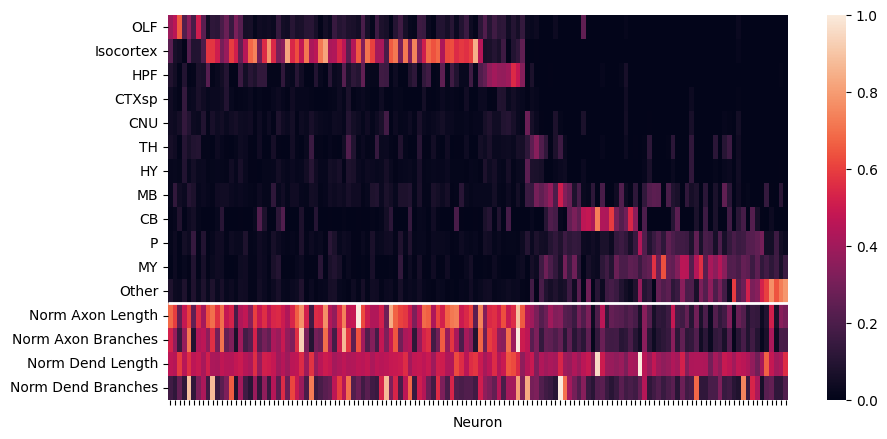

In [13]:
# Plot heatmap of projections
plotDF = fullDF.copy()
# Establish projection based sorting
sortProjDict = {}
for i, col in enumerate(sorted_rois):
    sortProjDict[col] = i
plotDF["Most Length"] = plotDF["Most Length"].map(sortProjDict)
plotDF = plotDF.sort_values("Most Length")[normDF.columns]

# Do plotting
plt.figure(figsize=(10,5))
sns.heatmap(plotDF.T, xticklabels = True, yticklabels = True)
# Clean up axes
plt.gca().set_xticklabels([])
plt.xlabel("Neuron")
plt.hlines([12], *plt.xlim(), colors = "white", linewidth = 2)
plt.savefig(SAVE_DIR.joinpath("figure 2 - projection heatmap sorted by top projection target.svg"),
            dpi=300,bbox_inches='tight', transparent = True)

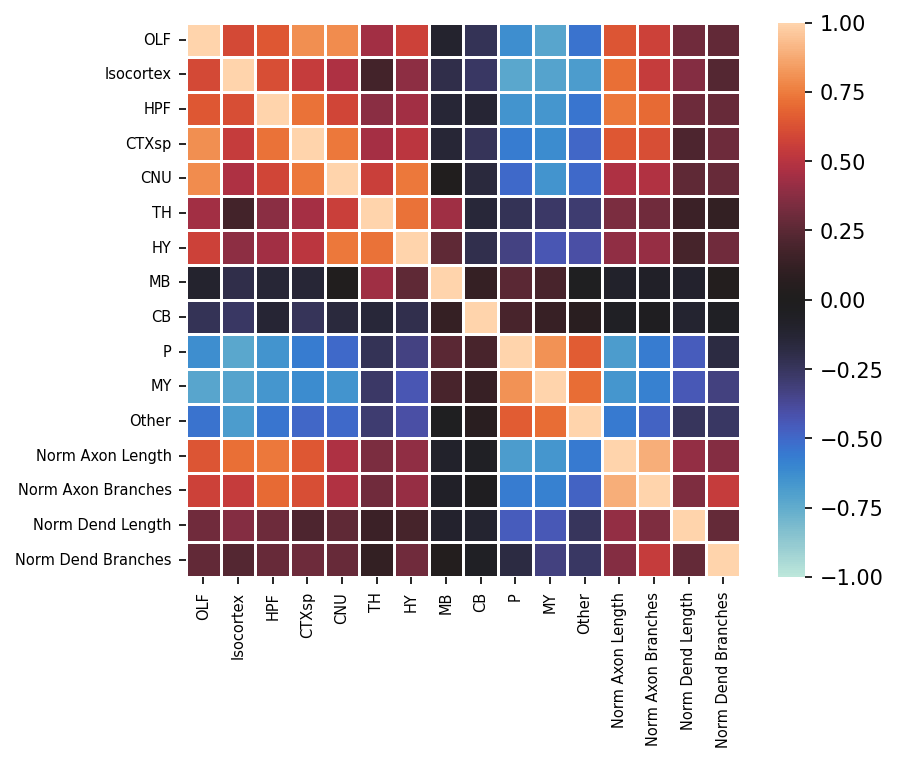

In [14]:
# Get correlation between features
corr_features = normDF.columns
corrMatrix = fullDF[corr_features].corr(method = "spearman")

# Do plotting
plt.figure(dpi=150)
sns.heatmap(corrMatrix, square = True, linewidths=.5, vmin = -1, vmax = 1, center = 0, cmap = "icefire")
plt.xticks(fontsize=7);
plt.yticks(fontsize=7);
plt.savefig(SAVE_DIR.joinpath("figure 2 - correlation matrix (spearman, proj + neuron features, diverging cmap).svg"),
            dpi=300, bbox_inches='tight', transparent = True)

### Plot neurons colored by soma position

In [15]:
useSC = False
feature = "somaDV"

# Plot with or without full spinal cord projections, which may increase visual clarity
if useSC:
    plotDF = dataDF.copy()
else:
    plotDF = dataDF[~dataDF["completeSC"]].copy()

# Setup colors, and normalize plotting values
cmap = sns.color_palette("viridis", as_cmap=True)
nMin = 4200
nMax = 5000
normVals = (plotDF[feature] - nMin) / (nMax - nMin)
normVals = normVals.clip(0,1).rename("normVal")
# normVals = norm_values.clip(0,1).rename("normVal")
plotDF = pd.merge(plotDF, normVals, left_index=True, right_index=True)

# Do plotting
plot = k3d.plot()
plot_ccf_mesh(acronym_to_id['root'], plot, color=rgb_to_hex(128,128,128), opacity=0.05)
for i, row in plotDF.iterrows():
    graph = graphs[row["Graph"]]
    r, g, b, _ = cmap(row["normVal"])
    color = rgb_to_hex(int(r*255),int(g*255), int(b*255))
    plot_graphs([graph],plot, color, opacity = .8, width = 1)

# Set camera
plot.grid_visible = False
plot.display()
time.sleep(0.5) # let display render before setting camera
plot.camera = sideviewHorizontal

Output()

In [16]:
with open(SAVE_DIR.joinpath("figure 2 - axons colored by DV soma position.html"), 'w') as f:
   f.write(plot.get_snapshot())

### Spatial distribution of top projection targets

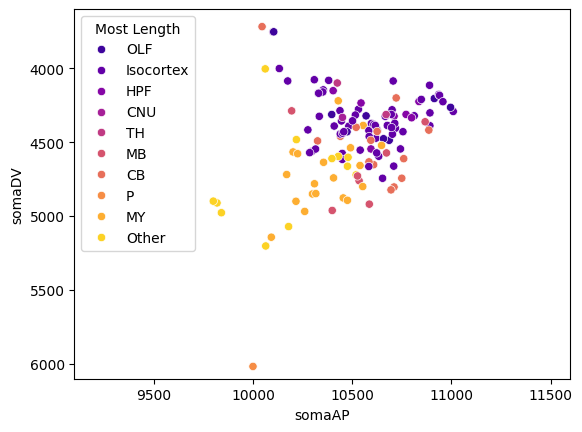

In [17]:
# Plot top projection target

# Only create colors for rois that are a top projection target
used_rois = sorted_rois.copy()
for indx in set(sorted_rois) - set(fullDF["Most Length"]):
    used_rois.remove(indx)

# Plot 
plt.figure()
sns.scatterplot(fullDF,x = "somaAP", y = "somaDV", hue = "Most Length", palette = "plasma", hue_order= used_rois)
plt.xlim([9100, 11600])
plt.ylim([3600, 6100])
plt.gca().invert_yaxis() # Invert the y-axis
plt.savefig(SAVE_DIR.joinpath("figure 2 - top projection target sagittal soma location.svg"),dpi=300, bbox_inches='tight')

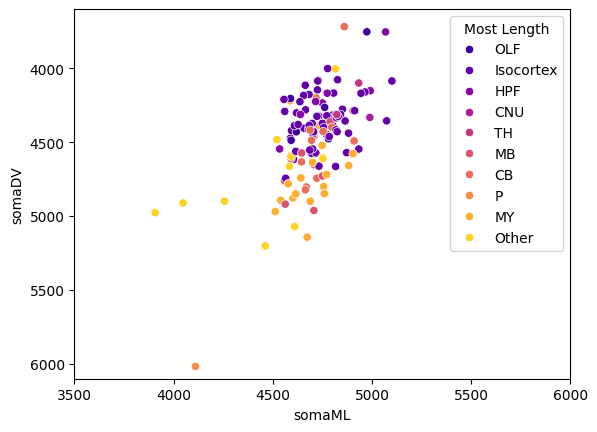

In [19]:
# Plot
plt.figure()
sns.scatterplot(fullDF,x = "somaML", y = "somaDV", hue = "Most Length", palette = "plasma", hue_order= used_rois)
plt.xlim([3500, 6000])
plt.ylim([3600, 6100])
plt.gca().invert_yaxis() # Invert the y-axis
plt.savefig(SAVE_DIR.joinpath("figure 2 - top projection target coronal soma location.svg"),dpi=300, bbox_inches='tight')